# Student Dropout Prediction Notebook

This notebook reproduces your script as a step-by-step workflow:
1. Load libraries and dataset
2. Clean and preprocess target labels
3. Visualize correlations and class-wise distributions
4. Train and evaluate a Random Forest classifier
5. Compare split seeds and cross-validation results
6. Plot normalized confusion matrix
7. Retrain using only 1% of training data

In [63]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.tree import plot_tree


## Question 1 
Load the dataset and display basic information

In [ ]:
# Question 1
# Load the dataset and display basic information about it
df = pd.read_csv('data.csv', sep=';')
df.info()

## Question 2
1. Visualise the data to see if any features are redundant and the overall distribution of the features within the two classes
2. Interpret the results

In [ ]:
# Clean column names in case they contain extra whitespace or quotes
df.columns = df.columns.str.strip().str.replace('"', '')

# Map Target to binary: 0=Dropout, 1=Enrolled/Graduate
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 1}
df['Target'] = df['Target'].map(target_mapping)

# Drop potential NaNs after mapping
df = df.dropna(subset=['Target'])

# Divide the dataset into features and target variable
features = df.drop('Target', axis=1) 
target = df['Target']

# Display class distribution
print(target.value_counts().rename(index={0: 'Dropout (0)', 1: 'Success (1)'}))

In [ ]:
# Correlation matrix to detect redundant features
plt.figure(figsize=(12, 10))
corr_matrix = features.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlation Matrix (Check for Redundancy)')
plt.show()

In [ ]:
# Normalize features for visualization
scaler = StandardScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)
features_scaled['Target'] = target.reset_index(drop=True).map({0: 'Dropout', 1: 'Success'})

# Show boxplots in groups of 7 features to see data distribution by class
features_per_plot = 6

for i, start in enumerate(range(0, len(features.columns), features_per_plot), start=1):
    chunk = features.columns[start:start + features_per_plot]
    # melt convertit le tableau en format long (Feature, Scaled Value, Target), qui est le format attendu par boxplot.
    data = features_scaled.melt(
        id_vars='Target',
        value_vars=chunk,
        var_name='Feature',
        value_name='Scaled Value'
    )

    plt.figure(figsize=(15, 5))
    sns.boxplot(data=data, x='Feature', y='Scaled Value', hue='Target', palette='Set2')
    plt.title(f'Normalized Feature Distributions - Group {i}')
    plt.xticks(rotation=35, ha='right')
    plt.show()

features_scaled = features_scaled.drop(columns='Target')

## Question 3
1. Split the dataset into a training set (90%) et a test set (10%)
2. Train a classifier using the algorithm of your choice
3. Calculate the classifier accuracy
4. Explain the algorithm
5. Where does the difference between the training and test accuracy come from?

In [ ]:
# Split dataset 90/10
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.10, random_state=42)

# Train Random Forest
clf = RandomForestClassifier(random_state=42)
clf.fit(features_train, target_train)
one_tree = clf.estimators_[0]
plt.figure(figsize=(12, 8))
plot_tree(one_tree, filled=True, feature_names=features.columns, class_names=['Dropout (0)', 'Success (1)'])
plt.show()

train_acc = accuracy_score(target_train, clf.predict(features_train))
test_acc = accuracy_score(target_test, clf.predict(features_test))

print(f'Training Accuracy: {train_acc:.4f}')
print(f'Testing Accuracy: {test_acc:.4f}')

# Optional full report
print('\nClassification Report (test split):')
print(classification_report(target_test, clf.predict(features_test), target_names=['Dropout (0)', 'Success (1)']))

#### Explain the algorithm
The Random Forest algorithm builds a lot of decision trees (100 in this case), each trained differently, and makes them vote together. The final prediction is the majority answer across all trees.

Two mechanisms make each tree different from the others :
- Bagging : each tree is trained on a random subset of the data (with replacement)
- Feature randomness : at each split, each tree only considers a random subset of variables — not all of them

#### Where does the difference between the training and test accuracy come from?
Because the classifier is trained with the values of the training set, it is optimized to classify the data from that set correctly. The test set has data that the model has never seen.

The main cause is overfitting. Overfitting is when the model learns the training data too well, instead of learning general patterns.

## Question 4
1. Change the random seed of the train/test split
2. Why is the result different
3. Do a more through evaluation aggregating several different splits

In [ ]:
# Change random seed and evaluate
features_train_seed, features_test_seed, target_train_seed, target_test_seed = train_test_split(
    features, target, test_size=0.10, random_state=99
)

clf_seed = RandomForestClassifier(random_state=42)
clf_seed.fit(features_train_seed, target_train_seed)

print(f'Testing Accuracy with seed 99: {accuracy_score(target_test_seed, clf_seed.predict(features_test_seed)):.4f}')

# 10-fold cross-validation
# The dataset is divided into 10 parts, and the model is trained on 9 parts and tested on the remaining part, repeated 10 times. This provides a more robust estimate of model performance across different subsets of data.
cv_scores = cross_val_score(RandomForestClassifier(random_state=42), features, target, cv=10)
print(f'10-Fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})')

#### Why is the result different?
Computers can't generate truly random numbers, they use a deterministic algorithm that produces a sequence of numbers that looks random. The seed is the starting value of that algorithm.

Same seed → same sequence of "random" numbers → same split
Different seed → different sequence → different split

## Question 5
1. Compute the transition matrix on your test set predictions (normalizing each row to sum 1) and explain it.
2. What are the true/false positives and the true/false negatives?
3. Compute the F1 score
4. What is the advantage compared to the accuracy measure?

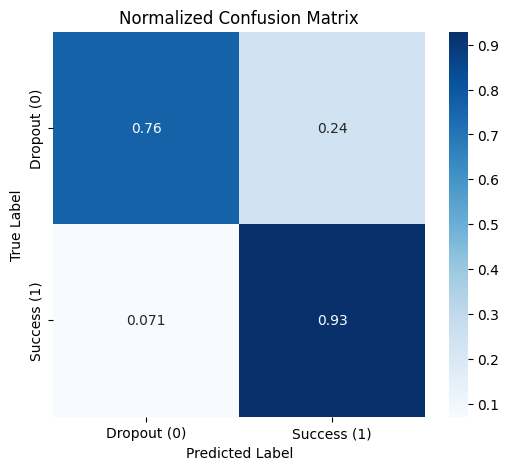

Accuracy: 0.8736
F1 Score: 0.9076


In [64]:
# Normalized confusion matrix + F1 score
target_pred = clf.predict(features_test)
cm_normalized = confusion_matrix(target_test, target_pred, normalize='true')

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_normalized,
    annot=True,
    cmap='Blues',
    xticklabels=['Dropout (0)', 'Success (1)'],
    yticklabels=['Dropout (0)', 'Success (1)']
)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Normalized Confusion Matrix')
plt.show()

acc_q5 = accuracy_score(target_test, target_pred)
f1_q5 = f1_score(target_test, target_pred)

print(f'Accuracy: {acc_q5:.4f}')
print(f'F1 Score: {f1_q5:.4f}')

#### What are the true/false positives and the true/false negatives?
True Positive (TP) — the model predicted YES, and it actually IS yes. Correct prediction.

True Negative (TN) — the model predicted NO, and it actually IS no. Correct prediction.

False Positive (FP) — the model predicted YES, but it's actually NO. The model raised a false alarm. 

False Negative (FN) — the model predicted NO, but it's actually YES. The model missed something.

#### What is the advantage of F1 score compared to accuracy?
Accuracy measures the global proportion of correct predictions, but it can be misleading when classes are imbalanced.

F1 score combines precision and recall in one metric:
- Precision: among predicted positives, how many are truly positive
- Recall: among real positives, how many the model finds

So F1 is more informative when the cost of false positives/false negatives matters or when one class is less frequent (common in dropout prediction).

## Question 6
1. Retrain your classifier with only 1% of the training set, and evaluate it on the same test set
2. Why is the result worse ?
3. Cant it be improved by decreasing the complexity of the classifier?

In [67]:
# Retrain with only 1% of the training set
features_train_1pct, _, target_train_1pct, _ = train_test_split(
    features_train, target_train,
    train_size=0.01,
    random_state=42,
    stratify=target_train
)

# Model with default complexity
clf_1pct_default = RandomForestClassifier(random_state=42)
clf_1pct_default.fit(features_train_1pct, target_train_1pct)
test_acc_1pct_default = accuracy_score(target_test, clf_1pct_default.predict(features_test))

# Model with reduced complexity
clf_1pct_simple = RandomForestClassifier(
    random_state=42,
    max_depth=5,
    min_samples_leaf=5,
    n_estimators=200
)
clf_1pct_simple.fit(features_train_1pct, target_train_1pct)
test_acc_1pct_simple = accuracy_score(target_test, clf_1pct_simple.predict(features_test))

print(f'Default test accuracy (full train): {test_acc:.4f}')
print(f'Test accuracy with 1% data (default RF): {test_acc_1pct_default:.4f}')
print(f'Test accuracy with 1% data (simpler RF): {test_acc_1pct_simple:.4f}')

Default test accuracy (full train): 0.8736
Test accuracy with 1% data (default RF): 0.8262
Test accuracy with 1% data (simpler RF): 0.8397


With only 1% of the training data, performance is worse because the model sees too few examples to learn stable and generalizable patterns.

This increases variance and makes predictions more sensitive to noise and random sampling effects.

Can decreasing complexity help? Yes, sometimes.
A simpler model (for example lower max_depth and higher min_samples_leaf) can reduce overfitting on tiny datasets and slightly improve test performance.

However, it cannot fully compensate for the lack of data: the main limitation is still the very small training sample.